## 1. Data Simulation

First, let's create a hypothetical logistics dataset using `pandas` and `numpy`. This dataset will include key variables as suggested in the task description.

In [ ]:
import pandas as pd
import numpy as np

# Set a random seed for reproducibility
np.random.seed(42)

# Number of data points
num_records = 1000

# Generate hypothetical data
data = {
    'order_id': range(1, num_records + 1),
    'order_date': pd.to_datetime('2023-01-01') + pd.to_timedelta(np.random.randint(0, 365, num_records), unit='D'),
    'delivery_date': pd.to_datetime('2023-01-01') + pd.to_timedelta(np.random.randint(1, 370, num_records), unit='D'),
    'shipment_volume_kg': np.random.uniform(50, 1000, num_records).round(2),
    'distance_km': np.random.uniform(10, 5000, num_records).round(2),
    'transportation_cost_usd': np.random.uniform(20, 5000, num_records).round(2),
    'warehouse_id': np.random.randint(1, 10, num_records),
    'delivery_status': np.random.choice(['Delivered', 'In Transit', 'Delayed', 'Cancelled'], num_records, p=[0.7, 0.15, 0.1, 0.05]),
    'delivery_time_hours': np.random.uniform(12, 240, num_records).round(2), # 0.5 to 10 days
    'customer_satisfaction_score': np.random.randint(1, 6, num_records)
}

df = pd.DataFrame(data)

# Ensure delivery_date is always after order_date
df['delivery_date'] = df.apply(lambda row: row['order_date'] + pd.to_timedelta(np.random.randint(1, 10), unit='D') if row['delivery_date'] < row['order_date'] else row['delivery_date'], axis=1)


print("Dataset created successfully. Here's a glimpse of the data:")
display(df.head())

print("\nData Info:")
display(df.info())

Dataset created successfully. Here's a glimpse of the data:


,order_id,order_date,delivery_date,shipment_volume_kg,distance_km,transportation_cost_usd,warehouse_id,delivery_status,delivery_time_hours,customer_satisfaction_score
0,1,2023-04-13,2023-09-17,792.70,2660.12,3377.81,5,Delivered,232.38,1
1,2,2023-12-15,2023-12-22,720.12,4210.20,48.48,9,In Transit,115.11,4
2,3,2023-09-28,2023-09-29,474.05,2905.31,2339.81,2,Delivered,44.56,5
3,4,2023-04-17,2023-04-18,871.01,2802.85,2864.39,2,Delivered,100.79,1
4,5,2023-03-13,2023-09-19,580.23,535.24,1534.07,9,Delivered,228.99,1



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   order_id                     1000 non-null   int64         
 1   order_date                   1000 non-null   datetime64[ns]
 2   delivery_date                1000 non-null   datetime64[ns]
 3   shipment_volume_kg           1000 non-null   float64       
 4   distance_km                  1000 non-null   float64       
 5   transportation_cost_usd      1000 non-null   float64       
 6   warehouse_id                 1000 non-null   int64         
 7   delivery_status              1000 non-null   object        
 8   delivery_time_hours          1000 non-null   float64       
 9   customer_satisfaction_score  1000 non-null   int64         
dtypes: datetime64[ns](2), float64(4), int64(3), object(1)
memory usage: 78.3+ KB


None

## 2. Exploratory Data Analysis (EDA)

Now that we have our simulated dataset, let's perform some Exploratory Data Analysis (EDA) to understand its characteristics, distributions, and potential relationships between variables.

### 2.1 Descriptive Statistics

Let's calculate descriptive statistics for numerical columns to understand their central tendencies and spread, and examine unique values for categorical columns.

In [ ]:
print("Descriptive statistics for numerical columns:")
display(df.describe())

print("\nValue counts for categorical columns (top 5 if many unique values):")
for column in df.select_dtypes(include='object').columns:
    print(f"\n--- {column} ---")
    display(df[column].value_counts().head())

print("\nMissing values:")
display(df.isnull().sum())

Descriptive statistics for numerical columns:


,order_id,order_date,delivery_date,shipment_volume_kg,distance_km,transportation_cost_usd,warehouse_id,delivery_time_hours,customer_satisfaction_score
count,1000.000000,1000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-01 13:22:04.800000,2023-09-04 11:57:07.199999744,518.144020,2595.285570,2471.807890,5.002000,125.092190,2.976000
min,1.000000,2023-01-01 00:00:00,2023-01-02 00:00:00,50.180000,12.210000,20.930000,1.000000,12.050000,1.000000
25%,250.750000,2023-04-08 00:00:00,2023-07-02 00:00:00,272.742500,1396.662500,1214.095000,3.000000,68.480000,2.000000
50%,500.500000,2023-07-01 12:00:00,2023-09-18 12:00:00,521.875000,2663.350000,2459.705000,5.000000,122.620000,3.000000
75%,750.250000,2023-09-27 06:00:00,2023-11-16 00:00:00,758.697500,3814.932500,3763.912500,7.000000,184.202500,4.000000
max,1000.000000,2023-12-31 00:00:00,2024-01-09 00:00:00,997.220000,4998.570000,4988.160000,9.000000,239.820000,5.000000
std,288.819436,NaN,NaN,273.545602,1417.508829,1451.242263,2.584701,65.738384,1.448973



Value counts for categorical columns (top 5 if many unique values):

--- delivery_status ---


,count
delivery_status,
Delivered,705
In Transit,150
Delayed,87
Cancelled,58



Missing values:


,0
order_id,0
order_date,0
delivery_date,0
shipment_volume_kg,0
distance_km,0
transportation_cost_usd,0
warehouse_id,0
delivery_status,0
delivery_time_hours,0
customer_satisfaction_score,0


In [ ]:
print("Missing values:")
display(df.isnull().sum())

Missing values:


,0
order_id,0
order_date,0
delivery_date,0
shipment_volume_kg,0
distance_km,0
transportation_cost_usd,0
warehouse_id,0
delivery_status,0
delivery_time_hours,0
customer_satisfaction_score,0


### 2.2 Correlation Analysis

Let's analyze the correlation between numerical variables to identify strong relationships that might indicate key drivers or dependencies.

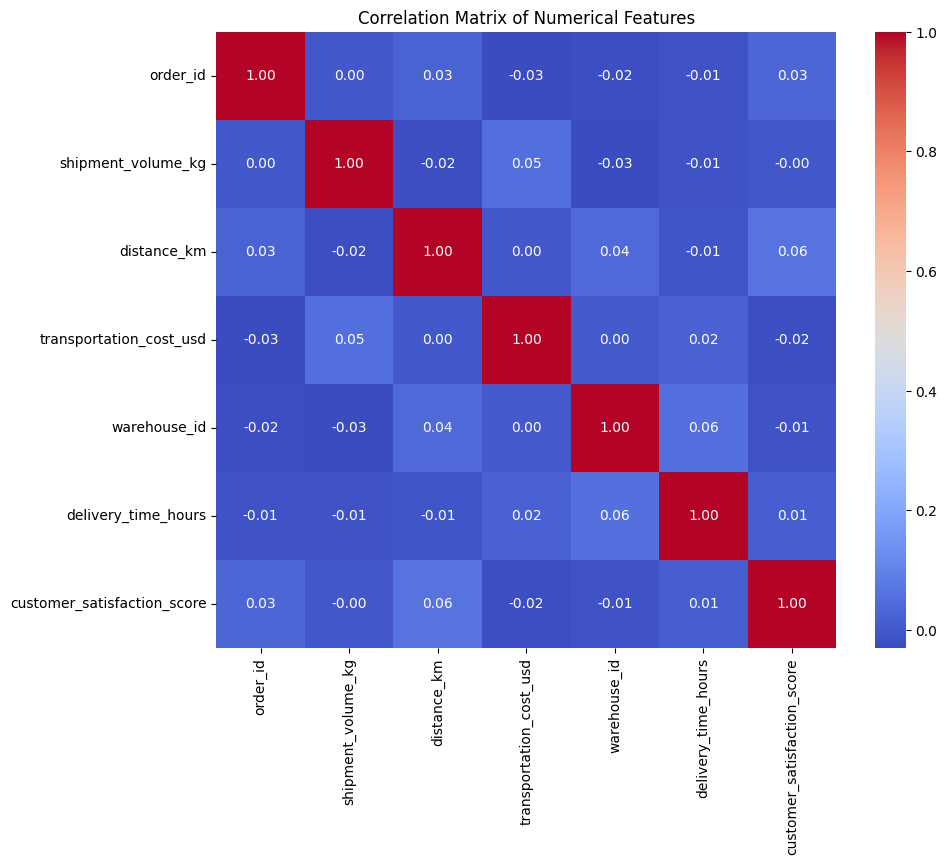

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## 3. Visualizations

Now, let's create various visualizations to capture trends, distributions, and relationships among key variables. We will justify the choice of each visualization method.

### 3.1 Distribution of Delivery Status

A bar plot is suitable here to show the frequency of each delivery status, giving us an immediate understanding of operational success and failure rates.

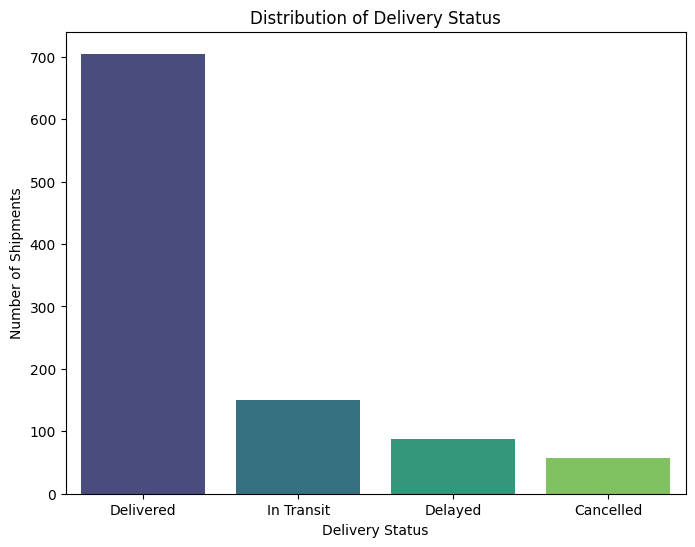

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='delivery_status', hue='delivery_status', palette='viridis', legend=False)
plt.title('Distribution of Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Number of Shipments')
plt.show()

### 3.2 Distribution of Key Numerical Variables

Histograms are effective for displaying the distribution of a single numerical variable. They help us understand the frequency of values within different ranges, revealing the shape of the distribution (e.g., normal, skewed) and potential outliers.

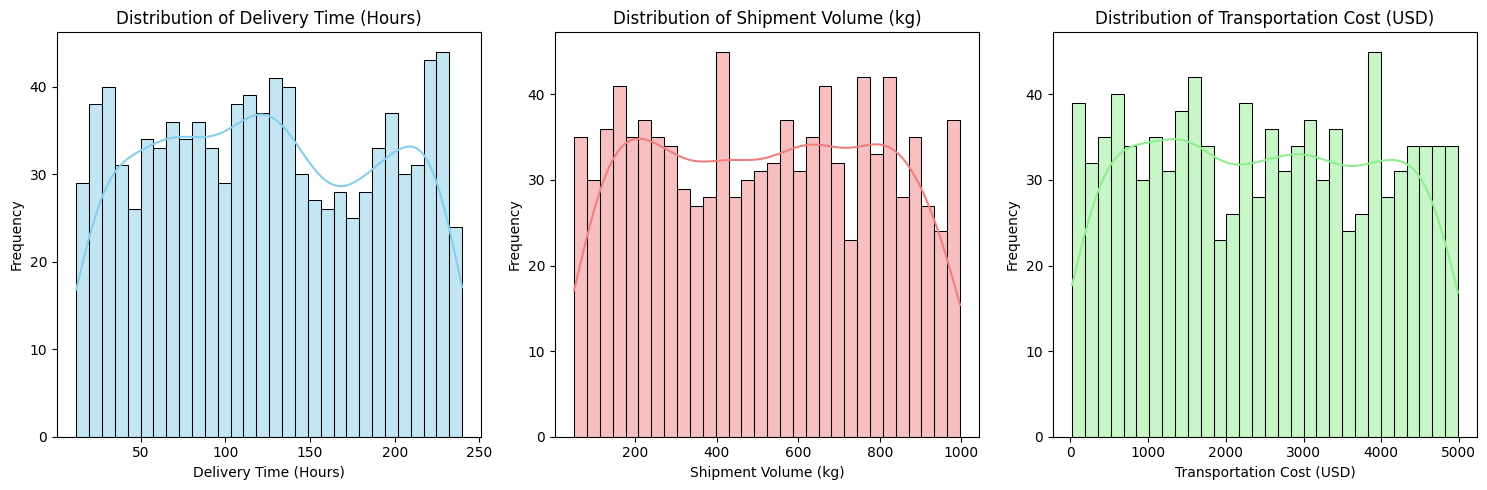

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['delivery_time_hours'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Delivery Time (Hours)')
plt.xlabel('Delivery Time (Hours)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.histplot(df['shipment_volume_kg'], kde=True, bins=30, color='lightcoral')
plt.title('Distribution of Shipment Volume (kg)')
plt.xlabel('Shipment Volume (kg)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
sns.histplot(df['transportation_cost_usd'], kde=True, bins=30, color='lightgreen')
plt.title('Distribution of Transportation Cost (USD)')
plt.xlabel('Transportation Cost (USD)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### 3.3 Relationship between Distance and Transportation Cost

A scatter plot is ideal for visualizing the relationship between two numerical variables. We expect a positive correlation here, where increased distance generally leads to higher transportation costs.

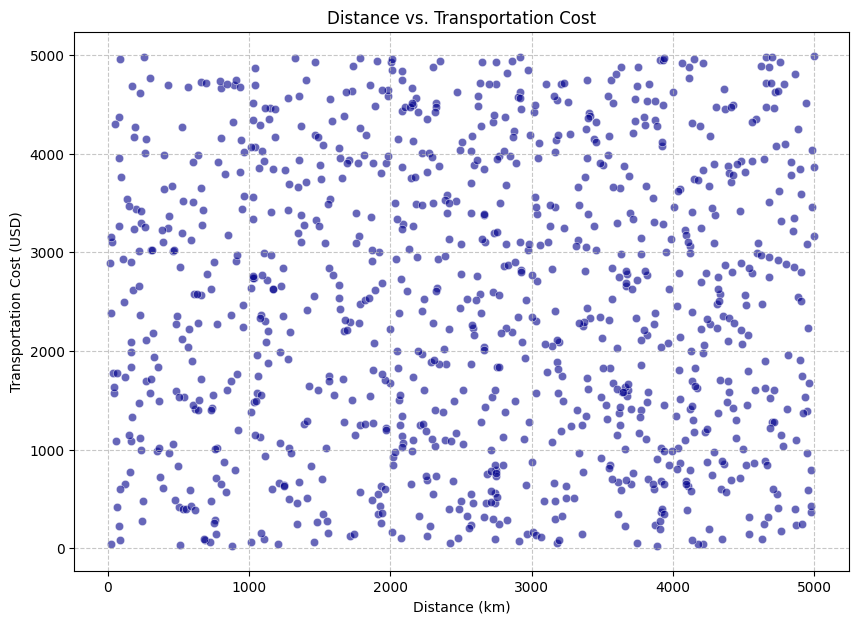

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='distance_km', y='transportation_cost_usd', alpha=0.6, color='darkblue')
plt.title('Distance vs. Transportation Cost')
plt.xlabel('Distance (km)')
plt.ylabel('Transportation Cost (USD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 3.4 Delivery Time vs. Customer Satisfaction

This scatter plot helps us understand if there's a relationship between how long a delivery takes and how satisfied customers are. We might expect to see lower satisfaction with longer delivery times.

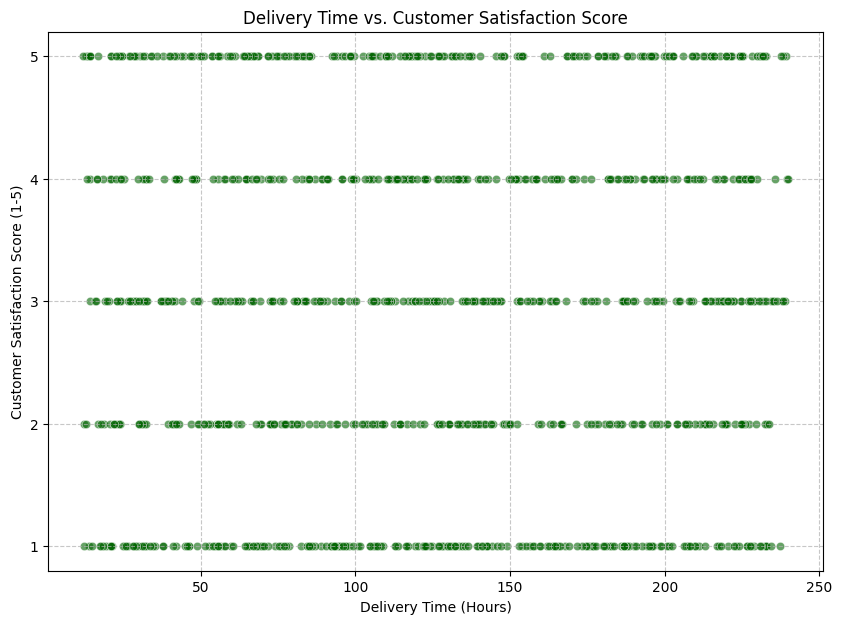

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='delivery_time_hours', y='customer_satisfaction_score', alpha=0.6, color='darkgreen')
plt.title('Delivery Time vs. Customer Satisfaction Score')
plt.xlabel('Delivery Time (Hours)')
plt.ylabel('Customer Satisfaction Score (1-5)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.yticks(range(1, 6)) # Set y-axis ticks for satisfaction scores
plt.show()

### 3.5 Shipment Volume by Warehouse

To understand the workload and potential capacity issues of different warehouses, a bar plot showing the total shipment volume handled by each warehouse is very useful.

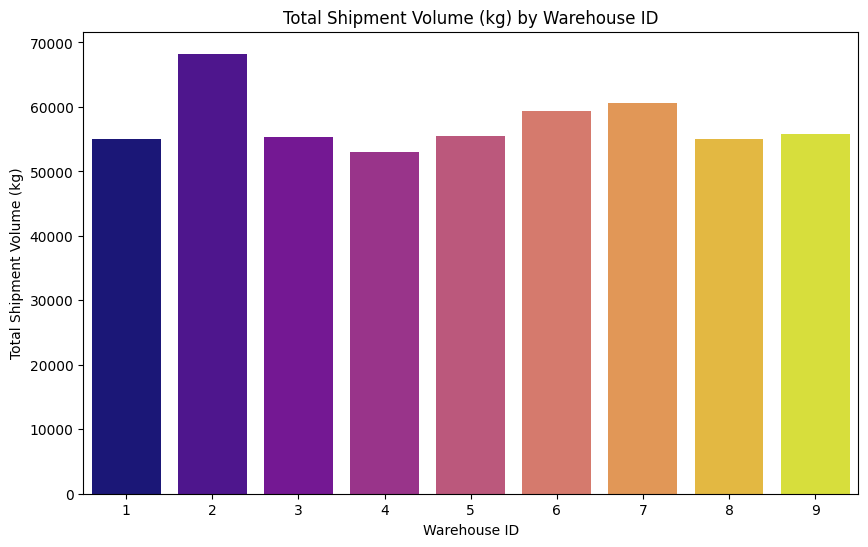

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a random seed for reproducibility
np.random.seed(42)

# Number of data points
num_records = 1000

# Generate hypothetical data
data = {
    'order_id': range(1, num_records + 1),
    'order_date': pd.to_datetime('2023-01-01') + pd.to_timedelta(np.random.randint(0, 365, num_records), unit='D'),
    'delivery_date': pd.to_datetime('2023-01-01') + pd.to_timedelta(np.random.randint(1, 370, num_records), unit='D'),
    'shipment_volume_kg': np.random.uniform(50, 1000, num_records).round(2),
    'distance_km': np.random.uniform(10, 5000, num_records).round(2),
    'transportation_cost_usd': np.random.uniform(20, 5000, num_records).round(2),
    'warehouse_id': np.random.randint(1, 10, num_records),
    'delivery_status': np.random.choice(['Delivered', 'In Transit', 'Delayed', 'Cancelled'], num_records, p=[0.7, 0.15, 0.1, 0.05]),
    'delivery_time_hours': np.random.uniform(12, 240, num_records).round(2), # 0.5 to 10 days
    'customer_satisfaction_score': np.random.randint(1, 6, num_records)
}

df = pd.DataFrame(data)

# Ensure delivery_date is always after order_date
df['delivery_date'] = df.apply(lambda row: row['order_date'] + pd.to_timedelta(np.random.randint(1, 10), unit='D') if row['delivery_date'] < row['order_date'] else row['delivery_date'], axis=1)

plt.figure(figsize=(10, 6))
warehouse_volume = df.groupby('warehouse_id')['shipment_volume_kg'].sum().sort_values(ascending=False)
sns.barplot(x=warehouse_volume.index, y=warehouse_volume.values, hue=warehouse_volume.index, palette='plasma', legend=False)
plt.title('Total Shipment Volume (kg) by Warehouse ID')
plt.xlabel('Warehouse ID')
plt.ylabel('Total Shipment Volume (kg)')
plt.show()